In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
insurance_data=pd.read_csv("insurance.csv")
insurance_data.sample(5)   

,age,sex,bmi,children,smoker,region,charges
205,28,female,28.880,1,no,northeast,4337.73520
319,32,male,37.335,1,no,northeast,4667.60765
229,47,male,25.460,2,no,northeast,9225.25640
1217,29,male,37.290,2,no,southeast,4058.11610
496,31,female,23.600,2,no,southwest,4931.64700


Text(0.5, 1.0, 'Bmi Vs charges')

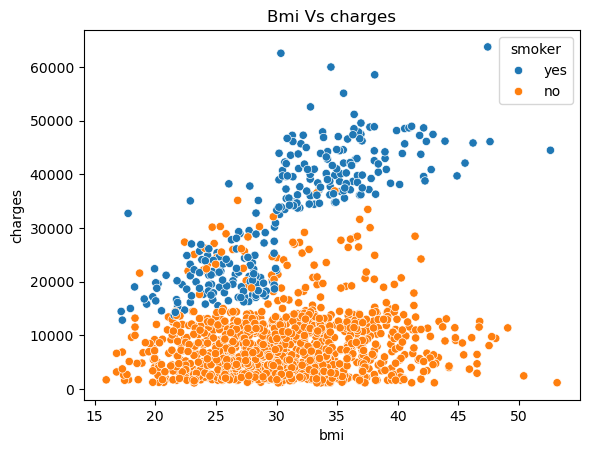

In [4]:
sns.scatterplot(
    x=insurance_data["bmi"],
    y=insurance_data["charges"],
    hue=insurance_data["smoker"]
)
plt.title("Bmi Vs charges")    

In [5]:
X=insurance_data.drop(columns=["charges","region"])
y=insurance_data["charges"]
X["sex"]=X["sex"].map({"female":1,"male":0})
X["smoker"]=X["smoker"].map({"yes":1,"no":0})


In [6]:
X.head()

,age,sex,bmi,children,smoker
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0


In [ ]:
# Train Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42) 

In [8]:
X_train.head()

,age,sex,bmi,children,smoker
560,46,1,19.95,2,0
1285,47,1,24.32,0,0
1142,52,1,24.86,0,0
969,39,1,34.32,5,0
486,54,1,21.47,3,0


In [9]:
# Train Model => LinearRegression
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
# Predict Values
y_pred=model.predict(X_test)

In [12]:
y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

In [14]:
# Evaluate => R-squared value
from sklearn.metrics import r2_score

r2=r2_score(y_test, y_pred)
print(f"R-squraed value : {r2}")

# Adjust R - Squared value => which predict output by removing unnacessary features 
# that does not effect logicaly but incease r-squared value

n = X_test.shape[0] # rows
p = X_test.shape[1] # cols

adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
print(f"Adjusted R-squred value : {adjusted_r2} ")


R-squraed value : 0.7811302113434097
Adjusted R-squred value : 0.7769533069797343 


In [ ]:
# Feature Engeenring => One Hot Coding

In [22]:
X=insurance_data.drop(columns=["charges"])
y=insurance_data["charges"]

X=pd.get_dummies(X,columns=["region"],drop_first=True,dtype=int)

X["sex"]=X["sex"].map({"female":1,"male":0})
X["smoker"]=X["smoker"].map({"yes":1,"no":0})

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

r2=r2_score(y_test, y_pred)
print(f"R-squraed value : {r2}")

R-squraed value : 0.7835929767120724


In [24]:
# Intraction Features
X=insurance_data.drop(columns=["charges"])
y=insurance_data["charges"]

X=pd.get_dummies(X,columns=["region"],drop_first=True,dtype=int)

X["sex"]=X["sex"].map({"female":1,"male":0})
X["smoker"]=X["smoker"].map({"yes":1,"no":0})

X["age_smoker"]=X["age"] * X["smoker"]
X["bmi_smoker"]=X["bmi"] * X["smoker"]

In [25]:
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.9
1,18,0,33.770,1,0,0,1,0,0,0.0
2,28,0,33.000,3,0,0,1,0,0,0.0
3,33,0,22.705,0,0,1,0,0,0,0.0
4,32,0,28.880,0,0,1,0,0,0,0.0


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model=LinearRegression()
model.fit(X_train,y_train) # training data => x,y ka training data pass karna
y_pred=model.predict(X_test) # prediction mein x ka test data pass krna

r2=r2_score(y_test, y_pred) # r2 mein output (y) k parameter pass krny => actual value and predicted value
print(f"R-squraed value : {r2}")

R-squraed value : 0.865231697953168


In [28]:
# Underfit Vs Overfit
# r2 training is low & r2 testing is low - underfit
# r2 training is very high >> & r2 testing is low - overfit 
y_train_pred=model.predict(X_train)
r2_train=r2_score(y_train,y_train_pred)

print(f"training data r2 : {r2_train}")
print(f"testing data r2 : {r2}")

training data r2 : 0.8340713711218875
testing data r2 : 0.865231697953168


In [126]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [127]:
df=pd.read_csv("house.csv")

In [128]:
df

,house_id,Type,Location,Area,Bath(s),Bedroom(s),Price
0,46326643,House,"DHA Defence, Lahore, Punjab",1 Kanal,6,5,75500000
1,46952582,House,"Bahria Orchard, Lahore, Punjab",8 Marla,5,5,25000000
2,47357581,House,"Paragon City, Lahore, Punjab",10 Marla,6,5,47000000
3,47397157,Flat,"Askari, Lahore, Punjab",10 Marla,3,3,28000000
4,43109993,House,"DHA Defence, Lahore, Punjab",8 Marla,5,4,43500000
...,...,...,...,...,...,...,...
17164,46266486,House,"PIA Housing Scheme, Lahore, Punjab",1 Kanal,6,7,49000000
17165,45309378,House,"DHA Defence, Lahore, Punjab",5 Marla,4,3,28000000
17166,38889542,House,"DHA Defence, Lahore, Punjab",1 Kanal,7,6,108500000
17167,38081209,House,"DHA Defence, Lahore, Punjab",1 Kanal,6,5,75500000


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17169 entries, 0 to 17168
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   house_id    17169 non-null  int64 
 1   Type        17169 non-null  object
 2   Location    17169 non-null  object
 3   Area        17169 non-null  object
 4   Bath(s)     17169 non-null  int64 
 5   Bedroom(s)  17169 non-null  int64 
 6   Price       17169 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 939.1+ KB


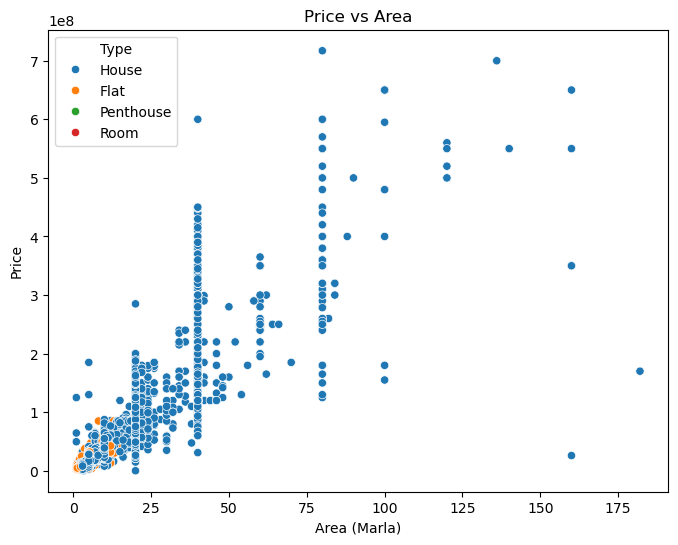

In [162]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(x=df["Area_Marla"], y=df["Price"], hue=df["Type"])
plt.title("Price vs Area")
plt.xlabel("Area (Marla)")
plt.ylabel("Price")
plt.show()

In [130]:
# Handling categorical data
def area_to_marla(value):
    value = value.lower().strip()
    
    if "kanal" in value:
        number = float(value.split()[0])
        return number * 20
    
    elif "marla" in value:
        number = float(value.split()[0])
        return number
    
    else:
        return None


In [131]:
df["Area_Marla"] = df["Area"].apply(area_to_marla)

In [132]:
df.drop(columns=["Area","Location"])


,house_id,Type,Bath(s),Bedroom(s),Price,Area_Marla
0,46326643,House,6,5,75500000,20.0
1,46952582,House,5,5,25000000,8.0
2,47357581,House,6,5,47000000,10.0
3,47397157,Flat,3,3,28000000,10.0
4,43109993,House,5,4,43500000,8.0
...,...,...,...,...,...,...
17164,46266486,House,6,7,49000000,20.0
17165,45309378,House,4,3,28000000,5.0
17166,38889542,House,7,6,108500000,20.0
17167,38081209,House,6,5,75500000,20.0


In [133]:
X=df.drop(columns=["Price","Location","Area"])
y=df["Price"]
X["Type"]=X["Type"].map({"House":1,"Flat":0})
X["Type"]=X["Type"].ffill()

In [134]:
X.head()

,house_id,Type,Bath(s),Bedroom(s),Area_Marla
0,46326643,1.0,6,5,20.0
1,46952582,1.0,5,5,8.0
2,47357581,1.0,6,5,10.0
3,47397157,0.0,3,3,10.0
4,43109993,1.0,5,4,8.0


In [135]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [136]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13735 entries, 11067 to 15795
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   house_id    13735 non-null  int64  
 1   Type        13735 non-null  float64
 2   Bath(s)     13735 non-null  int64  
 3   Bedroom(s)  13735 non-null  int64  
 4   Area_Marla  13735 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 643.8 KB


In [137]:
# Train the model
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [138]:
# Prediction section
y_pred=model.predict(X_test)

In [139]:
print(len(y_test), len(y_pred))

3434 3434


In [140]:
r2=r2_score(y_test, y_pred) # r2 mein output (y) k parameter pass krny => actual value and predicted value
print(f"R-squraed value : {r2}")

R-squraed value : 0.7387565576315014


In [147]:
# FEATURE INTRACTION
X=df.drop(columns=["Price","Area"])
y=df["Price"]
X=pd.get_dummies(X,columns=["Location"],drop_first=True,dtype=int)
X["Type"]=X["Type"].map({"House":1,"Flat":0})
X["Type"]=X["Type"].ffill()

In [167]:
X.head()

,house_id,Type,Bath(s),Bedroom(s),Area_Marla,"Location_Abbot Road, Lahore, Punjab","Location_Abdalians Cooperative Housing Society, Lahore, Punjab","Location_Abid Road, Lahore, Punjab","Location_Afzal Park, Lahore, Punjab","Location_Ahlu Road, Lahore, Punjab",...,"Location_Wahdat Colony, Lahore, Punjab","Location_Walton Railway Officers Colony, Lahore, Punjab","Location_Walton Road, Lahore, Punjab","Location_Wapda Town, Lahore, Punjab","Location_Waris Road, Lahore, Punjab","Location_West Wood Housing Society, Lahore, Punjab","Location_Zaheer Villas, Lahore, Punjab","Location_Zaitoon City, Lahore, Punjab","Location_Zaman Colony, Lahore, Punjab","Location_Zohra Homes, Lahore, Punjab"
0,46326643,1.0,6,5,20.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,46952582,1.0,5,5,8.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,47357581,1.0,6,5,10.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,47397157,0.0,3,3,10.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,43109993,1.0,5,4,8.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [150]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
r2=r2_score(y_test, y_pred) # r2 mein output (y) k parameter pass krny => actual value and predicted value
print(f"R-squraed value : {r2}")

R-squraed value : 0.7602483674821727


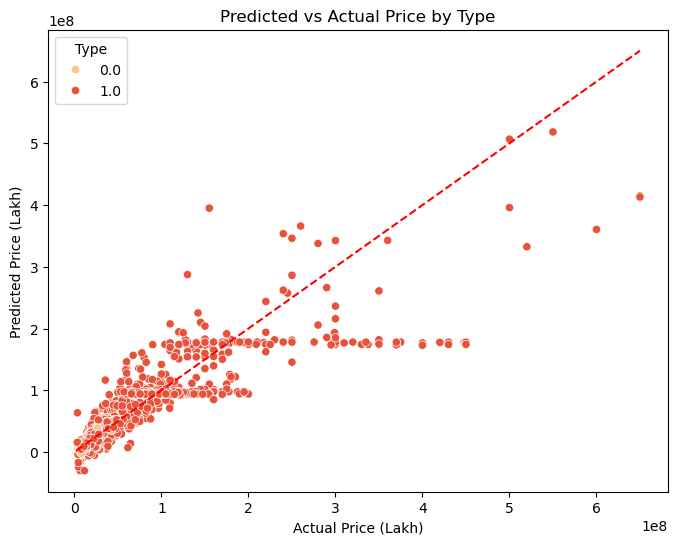

In [168]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Combine actual, predicted, and Type into a DataFrame
df_plot = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Type": X_test["Type"]  # make sure X_test has the same indices as y_test
})

# Step 2: Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_plot, x="Actual", y="Predicted", hue="Type", palette="OrRd")
plt.plot([df_plot["Actual"].min(), df_plot["Actual"].max()],
         [df_plot["Actual"].min(), df_plot["Actual"].max()],
         'r--')  # 45-degree line
plt.xlabel("Actual Price (Lakh)")
plt.ylabel("Predicted Price (Lakh)")
plt.title("Predicted vs Actual Price by Type")
plt.legend(title="Type")
plt.show()

